In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')

In [3]:
train.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [4]:
test.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
0,18524,3.0,No,7.0,4.0,No,6.0,NaN
1,18525,NaN,Yes,0.0,0.0,Yes,5.0,1.0
2,18526,3.0,No,5.0,6.0,No,15.0,9.0
3,18527,3.0,No,4.0,4.0,No,5.0,6.0
4,18528,9.0,Yes,1.0,2.0,Yes,1.0,1.0


In [5]:
# 2. 범주형 인코딩 (Yes/No → 0/1)
binary_cols = ["Stage_fear", "Drained_after_socializing"]

for col in binary_cols:
    train[col] = train[col].map({"No": 0, "Yes": 1})
    test[col] = test[col].map({"No": 0, "Yes": 1})

In [6]:
print(train.columns.tolist())

['id', 'Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency', 'Personality']


In [7]:
# 3. 타겟 인코딩 (Extrovert / Introvert)


# =============================
label = LabelEncoder()
train['Personality'] = label.fit_transform(train["Personality"])
# Extrovert=1, Introvert=0  (보통 이렇게 됨)

In [8]:
# =============================
# 4. feature/target 분리
# =============================
X = train.drop("Personality", axis=1)
y = train["Personality"]

In [9]:
# 5. 결측치 처리 (숫자는 median으로 대체)
# =============================
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)
test_filled = imputer.transform(test)

In [10]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X, y)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
# 7. test 데이터 예측
# =============================
pred = model.predict(test_filled)

# 디코딩 (0/1 → Introvert/Extrovert)
pred_labels = label.inverse_transform(pred)

print(pred_labels)


['Extrovert' 'Introvert' 'Extrovert' ... 'Extrovert' 'Extrovert'
 'Introvert']


In [12]:
# 8. 예측 결과 CSV로 저장
# =============================

# test 데이터에 id가 있다고 가정
submission = pd.DataFrame({
    "id": test["id"],
    "Personality": pred_labels
})

submission.to_csv("submission.csv", index=False)

print("CSV 저장 완료: submission.csv")


CSV 저장 완료: submission.csv


In [13]:
# ============================================
# 9. Train / Validation Split 후 정확도 평가
# ============================================

# 원본 train 데이터를 다시 feature/target 분리 (imputer 적용 전)
X_raw = train.drop("Personality", axis=1)
y = train["Personality"]

# 결측치 처리
X_filled = imputer.fit_transform(X_raw)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_filled, y, test_size=0.2, random_state=42
)

# 모델 다시 학습 (train split 기준)
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

# 검증 정확도 계산
valid_pred = model.predict(X_valid)
accuracy = accuracy_score(y_valid, valid_pred)

print("Validation Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_valid, valid_pred))


Validation Accuracy: 0.968421052631579

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      2753
           1       0.95      0.93      0.94       952

    accuracy                           0.97      3705
   macro avg       0.96      0.96      0.96      3705
weighted avg       0.97      0.97      0.97      3705



In [14]:
train.isnull()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...
18519,False,False,False,False,False,False,False,False,False
18520,False,False,True,False,False,False,False,False,False
18521,False,False,False,False,False,False,False,True,False
18522,False,True,False,False,False,False,False,False,False


In [15]:
test.isnull()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
0,False,False,False,False,False,False,False,True
1,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
6170,False,False,False,False,False,False,False,False
6171,False,False,False,False,False,False,False,False
6172,False,False,False,False,False,False,False,False
6173,False,False,False,False,False,False,False,False


/opt/homebrew/lib/python3.11/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


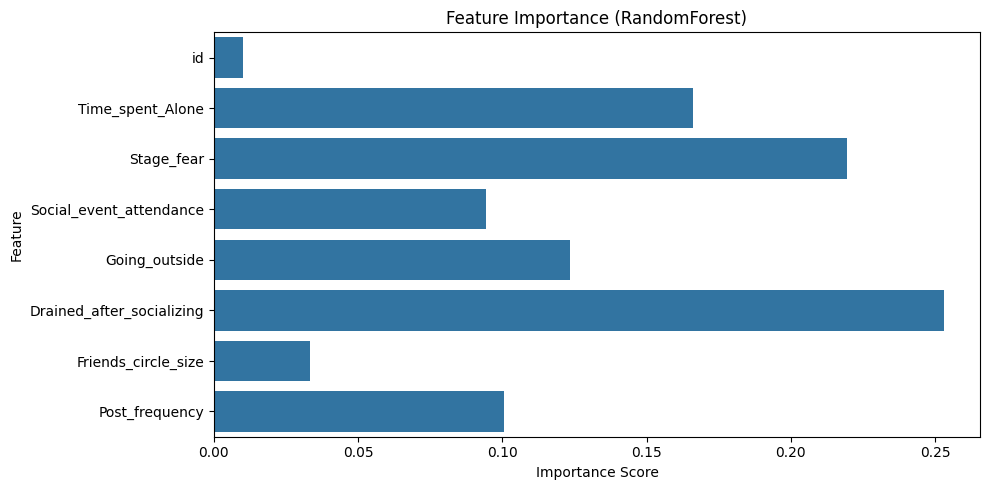

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
features = train.drop("Personality", axis=1).columns

plt.figure(figsize=(10,5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance (RandomForest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score: 0.9688914883030462
